## **Kernel Tricks in Support Vector Machines (SVM)**

### **Topic Roadmap**

**1. Environment Setup and Data Generation**

**2. The Problem with Linear Boundaries on Non-Linear Data**

**3. The RBF Kernel Trick**

**4. The Polynomial Kernel Trick**

### **1. Environment Setup and Data Generation**

Import standard libraries and generate a dataset forming concentric circles. This topology is impossible to separate with a straight line, making it perfect for demonstrating the necessity of the Kernel Trick.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

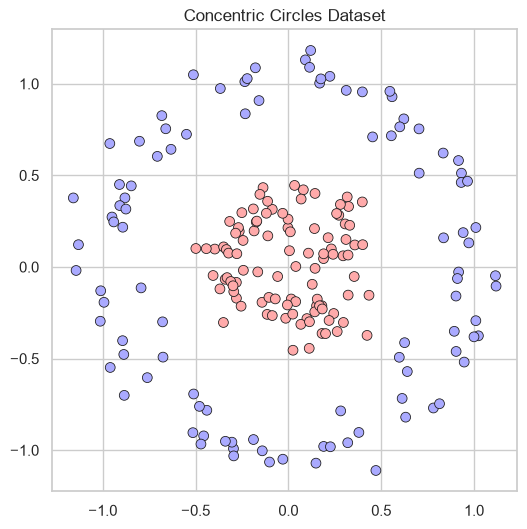

In [2]:
# Generate Non-Linear Circular Dataset
X, y = make_circles(n_samples=200, factor=0.3, noise=0.1, random_state=42)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="bwr", s=50, edgecolor="k", legend=False)
plt.title("Concentric Circles Dataset")
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

### **2. The Problem with Linear Boundaries on Non-Linear Data**

Attempting to classify circular data using a standard Linear SVM fails dramatically because a straight line cannot encapsulate the inner circle.

In [4]:
# Train a Linear SVM
lin_classifier = SVC(kernel="linear")
lin_classifier.fit(X_train, y_train)

y_pred_lin = lin_classifier.predict(X_test)
print(f"Linear Kernel Accuracy: {accuracy_score(y_test, y_pred_lin):.4f}")

Linear Kernel Accuracy: 0.6250


### **3. The RBF Kernel Trick**

The Radial Basis Function (RBF) kernel conceptually projects the 2D data into infinite dimensions based on distance from a center point, allowing a hyperplane to slice the top "dome" off, which projects back to 2D as a circular boundary.

In [5]:
# Train an RBF Kernel SVM
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)

y_pred_rbf = rbf_classifier.predict(X_test)
print(f"RBF Kernel Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")

RBF Kernel Accuracy: 1.0000


### **4. The Polynomial Kernel Trick**

The Polynomial kernel mathematically computes the dot products of the data as if they were expanded into a polynomial feature space, creating complex, curved boundaries without explicitly computing the new coordinates.

In [6]:
# Train a Polynomial Kernel SVM (Degree 2)
poly_classifier = SVC(kernel="poly", degree=2)
poly_classifier.fit(X_train, y_train)

y_pred_poly = poly_classifier.predict(X_test)
print(f"Polynomial Kernel Accuracy: {accuracy_score(y_test, y_pred_poly):.4f}")

Polynomial Kernel Accuracy: 1.0000


### **Key Revision Notes**

- **What is a Kernel?** A function that computes the similarity (dot product) between two vectors in a higher-dimensional space without ever actually transforming the vectors into that space.
- **Why is it a "Trick"?** Computing the coordinates of high-dimensional feature spaces is computationally expensive or impossible (RBF has infinite dimensions). Kernels calculate the necessary dot products directly from the original lower-dimensional data, saving massive computational overhead.
- **RBF (Radial Basis Function):** The default and most powerful kernel for general non-linear data. It acts like a similarity measure based on distance.
- **Polynomial:** Useful when the decision boundary has a specific known polynomial shape (like the degree=2 quadratic shape needed for the circle dataset).